FEATURE ENGINEERING

In [9]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv("../data/atp_matches_2000_2019_clean.csv")
df_clean = df.copy()


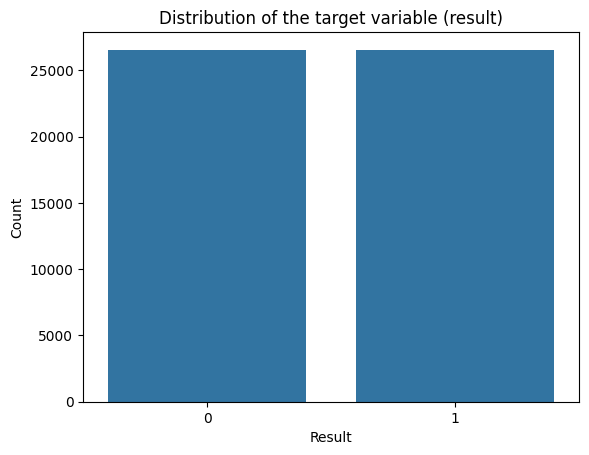

In [10]:
#RANDOMIZING THE WINNER AND LOSER COLUMNS
#-----------------------------------------------
#first, draw which side will be the winner.
np.random.seed(42)
mask = np.random.rand(len(df_clean)) < 0.5

winner_cols = [c for c in df_clean.columns if c.startswith(("winner_", "w_"))]

for w_col in winner_cols:

    if w_col.startswith("winner_"):
        l_col = w_col.replace("winner_", "loser_")
        base = w_col[len("winner_"):]

    else:  # w_ stats
        l_col = w_col.replace("w_", "l_")
        base = w_col[len("w_"):]

    df_clean[f"player1_{base}"] = np.where(mask, df_clean[w_col], df_clean[l_col])
    df_clean[f"player2_{base}"] = np.where(mask, df_clean[l_col], df_clean[w_col])
    
#target variable
df_clean["result"] = np.where(mask, 1, 0)

#Create a graph showing the distribution of the target variable.
sns.countplot(x="result", data=df_clean)
plt.title("Distribution of the target variable (result)")
plt.xlabel("Result")
plt.ylabel("Count")
plt.show()

In [11]:

#THE BASE DIFFERENTIAL VARIABLES
#1. Rank differential (1-2)
df_clean["rank_diff"] = df_clean["player1_rank"] - df_clean["player2_rank"]
#===================================
#2. Rank points differential (1-2)
df_clean["rank_points_diff"] = df_clean["player1_rank_points"] - df_clean["player2_rank_points"]
#===================================
#3. Age differential (1-2)
df_clean["age_diff"] = df_clean["player1_age"] - df_clean["player2_age"]
#===================================
#4. Height differential (1-2)
df_clean["height_diff"] = df_clean["player1_ht"] - df_clean["player2_ht"]

#5. Binary handedness (1 if different, 0 if same).
df_clean["different_hand"] = (
    df_clean["player1_hand"] != df_clean["player2_hand"]
).astype(int)


In [12]:
#ELO
ELO_START = 1500
K = 32
SCALE = 400
#Expected outcome Player 1 - Player 2
def expected_score(r1, r2, scale=400):
    return 1 / (1 + 10 ** ((r2 - r1) / scale))

#ELO change
def update_elo(r1, r2, score1, k=32, scale=400):
    e1 = expected_score(r1, r2, scale)
    r1_new = r1 + k * (score1 - e1) #playr1 elo update
    r2_new = r2 - k * (score1 - e1) #player2 elo update (note the minus, because score1 is from player1 perspective)
    return r1_new, r2_new

#Empty columns for pre-match ELO ratings
df_clean["elo_p1_pre"] = np.nan
df_clean["elo_p2_pre"] = np.nan

#ELO memory
elo_dict = {}

#Calculate ELO ratings iteratively
for i, row in df_clean.iterrows():
    
    p1 = row["player1_id"]
    p2 = row["player2_id"]
    score1 = row["result"]  # 1 = player1 wins
    
    #Current ELO or DEFAULT=1500
    r1 = elo_dict.get(p1, ELO_START)
    r2 = elo_dict.get(p2, ELO_START)
    
    #save pre-match ELO ratings
    df_clean.at[i, "elo_p1_pre"] = r1
    df_clean.at[i, "elo_p2_pre"] = r2
    
    #Update ELO
    r1_new, r2_new = update_elo(r1, r2, score1, k=K)
    
    elo_dict[p1] = r1_new
    elo_dict[p2] = r2_new
    
    #ELO differentials (1-2)
df_clean["elo_diff"] = df_clean["elo_p1_pre"] - df_clean["elo_p2_pre"]

#SURFACE-SPECIFIC ELO RATINGS
#Empty columns for pre-match surface-specific ELO ratings

df_clean["elo_p1_pre_surface"] = np.nan
df_clean["elo_p2_pre_surface"] = np.nan


surface_elo_dict = {}
for i, row in df_clean.iterrows():
    
    p1 = row["player1_id"]
    p2 = row["player2_id"]
    surface = row["surface"]
    score1 = row["result"]  # 1 = player1 wins
    
    #Keys for surface-specific ELO
    key1 = (p1, surface)
    key2 = (p2, surface)
    
    #Current ELO or DEFAULT=1500
    r1 = surface_elo_dict.get(key1, ELO_START)
    r2 = surface_elo_dict.get(key2, ELO_START)
    
    #save pre-match surface-specific ELO ratings
    df_clean.at[i, "elo_p1_pre_surface"] = r1
    df_clean.at[i, "elo_p2_pre_surface"] = r2
    
    #Update ELO
    r1_new, r2_new = update_elo(r1, r2, score1, k=K)
    
    surface_elo_dict[key1] = r1_new
    surface_elo_dict[key2] = r2_new
    
#Surface-specific ELO differential feature (1-2)
df_clean["elo_diff_surface"] = (df_clean["elo_p1_pre_surface"] - df_clean["elo_p2_pre_surface"])
df_clean.groupby("result")["elo_diff_surface"].mean()


result
0   -67.442052
1    68.754306
Name: elo_diff_surface, dtype: float64

In [13]:
#SERVE ADVANTAGE: 
#Serve points won
df_clean["p1_srv_pts_won"] = (
    df_clean["player1_1stWon"] +
    df_clean["player1_2ndWon"]
) / df_clean["player1_svpt"]

df_clean["p2_srv_pts_won"] = (
    df_clean["player2_1stWon"] +
    df_clean["player2_2ndWon"]
) / df_clean["player2_svpt"]

#Return points won
df_clean["p1_ret_pts_won"] = 1 - df_clean["p2_srv_pts_won"]
df_clean["p2_ret_pts_won"] = 1 - df_clean["p1_srv_pts_won"]

df_clean["p1_srv_hist"] = (
    df_clean
    .groupby("player1_id")["p1_srv_pts_won"]
    .transform(lambda s: s.shift(1).rolling(20, min_periods=5).mean())
)

df_clean["p2_srv_hist"] = (
    df_clean
    .groupby("player2_id")["p2_srv_pts_won"]
    .transform(lambda s: s.shift(1).rolling(20, min_periods=5).mean())
)

df_clean["p1_ret_hist"] = (
    df_clean
    .groupby("player1_id")["p1_ret_pts_won"]
    .transform(lambda s: s.shift(1).rolling(20, min_periods=5).mean())
)

df_clean["p2_ret_hist"] = (
    df_clean
    .groupby("player2_id")["p2_ret_pts_won"]
    .transform(lambda s: s.shift(1).rolling(20, min_periods=5).mean())
)

df_clean["serve_advantage_diff"] = (
    (df_clean["p1_srv_hist"] - df_clean["p2_ret_hist"]) -
    (df_clean["p2_srv_hist"] - df_clean["p1_ret_hist"])
).fillna(0)
#===================================
#COMPLETENESS FEATURE

#1. Match-level
df_clean["p1_complete"] = (
    df_clean["p1_srv_pts_won"] *
    df_clean["p1_ret_pts_won"]
)

df_clean["p2_complete"] = (
    df_clean["p2_srv_pts_won"] *
    df_clean["p2_ret_pts_won"]
)

#2. Historical completeness (historical 20-match rolling average of match-level completeness)
df_clean["p1_complete_hist"] = (
    df_clean
    .groupby("player1_id")["p1_complete"]
    .transform(lambda s: s.shift(1).rolling(20, min_periods=5).mean())
)

df_clean["p2_complete_hist"] = (
    df_clean
    .groupby("player2_id")["p2_complete"]
    .transform(lambda s: s.shift(1).rolling(20, min_periods=5).mean())
)

#Completeness diff feature (1-2)
df_clean["complete_diff"] = (
    df_clean["p1_complete_hist"].fillna(0) -
    df_clean["p2_complete_hist"].fillna(0)
)

#LAST-20 WIN PERCENTAGE (1-2)
df_clean["p1_win"] = df_clean["result"]
df_clean["p2_win"] = 1 - df_clean["result"]

df_clean["p1_form_hist"] = (
    df_clean
    .groupby("player1_id")["p1_win"]
    .transform(lambda s: s.shift(1).rolling(20, min_periods=5).mean())
)

df_clean["p2_form_hist"] = (
    df_clean
    .groupby("player2_id")["p2_win"]
    .transform(lambda s: s.shift(1).rolling(20, min_periods=5).mean())
)

#DIFF FEATURE (1-2)
df_clean["form_diff"] = (
    df_clean["p1_form_hist"].fillna(0) -
    df_clean["p2_form_hist"].fillna(0)
)


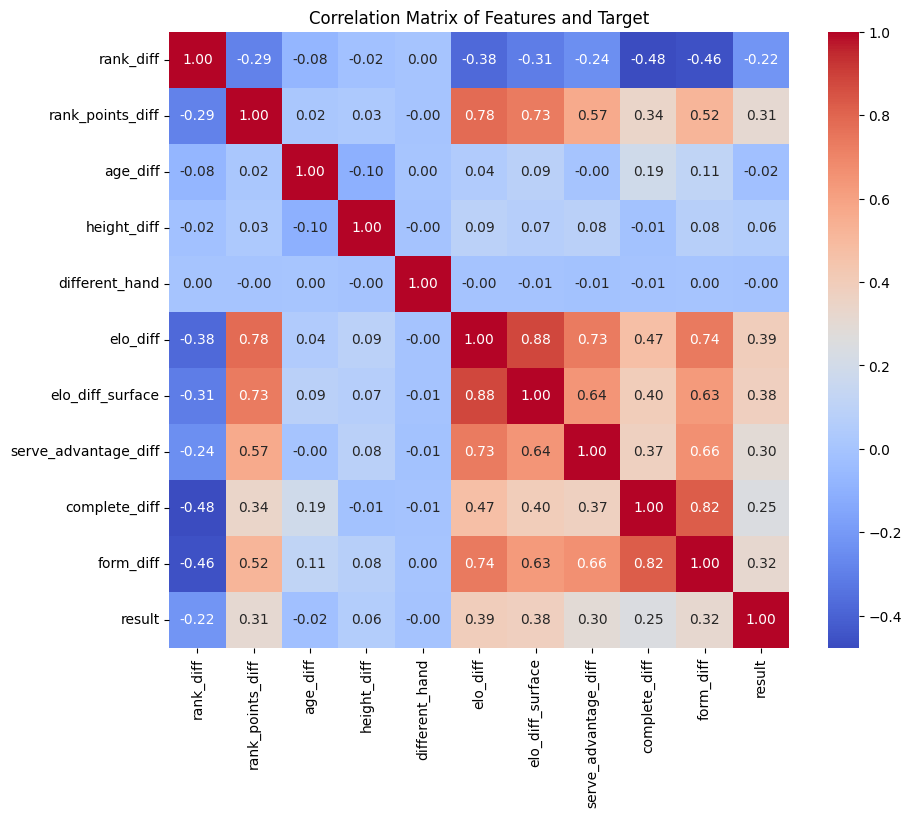

In [14]:
#correlation matrix with all features 
X = [
    "rank_diff",
    "rank_points_diff",
    "age_diff",
    "height_diff",
    "different_hand",
    "elo_diff",
    "elo_diff_surface",
    "serve_advantage_diff",
    "complete_diff",
    "form_diff",
]
corr_matrix = df_clean[X + ["result"]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Features and Target")
plt.show()

In [15]:
#save the data
df_clean.to_csv("../data/atp_matches_2000_2019_clean.csv", index=False)


In [16]:
X = [
    "rank_diff",
    "rank_points_diff",
    "age_diff",
    "height_diff",
    "different_hand",
    "elo_diff",
    "elo_diff_surface",
    "complete_diff",
    "serve_advantage_diff",
    "form_diff",
]

df_clean[X].agg(['min','max','mean','std']).T


,min,max,mean,std
rank_diff,-1998.000000,1991.000000,0.519294,146.042522
rank_points_diff,-16641.000000,16143.000000,5.612328,2149.071333
age_diff,-21.500000,25.900000,0.027407,5.235905
height_diff,-41.000000,40.000000,-0.015895,9.534323
different_hand,0.000000,1.000000,0.227989,0.419540
elo_diff,-919.171393,902.696522,0.663558,196.286453
elo_diff_surface,-845.666947,811.958004,0.662539,178.533020
complete_diff,-0.347139,0.325798,-0.000161,0.088412
serve_advantage_diff,-0.351658,0.288251,-0.000647,0.067097
form_diff,-1.000000,1.000000,0.000724,0.276198
